# **<p align="center"> Xi 1 Angle of Residues Analysis </p>**

## <ins> Description </ins>
### Explanation

<details open>
<summary> <font size="6"> <ins>Key Points 2 </ins> </font> </summary>

- bulletpoint1

-  bulletpoint1

- [link]()

- image1: <img src="" width = 50%>

</details>

</br>

<details open>
<summary> <font size = "6"> <ins> Key Points 2 </ins> </font> </summary>

- `bulletpoint1`


- `bulletpoint2`



</details>

</br>


In [1]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator
# General Purpose Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
# Molecular Libraries
import gemmi 
# from rdkit import Chem
# import parasail
# Local Libraries
from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats,  get_res_CoM , get_atom_coord
from xaidar.data.molecModels import flatten_pdb, createPDB, clear_empty
from xaidar.data.molecModels import sele_pdb, sele_Lig, sele_AA, sele_chain_name

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Test python objs
test_pdb_path = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb")
test_pdb = loadPDB(test_pdb_path)
test_prot = sele_pdb( test_pdb, sele_AA)
test_prot_mon = sele_pdb( test_prot, sele_chain_name, chain_name = "A")
test_lig = sele_pdb( test_pdb, sele_Lig)
test_chain = flatten_pdb( test_prot_mon, "chain" )
test_res = test_chain[0][0] 
test_atom =  test_res[0]

---


In [3]:
with open( rootdir.joinpath("data/ev2a/fragalysis/04-closestligtocentralprot/prot_dict.pkl"), "rb") as f:
    proteins_dict = pkl.load(f)

In [4]:
print(proteins_dict.keys())
print(proteins_dict["piperidine"].keys())
print(proteins_dict["piperidine"]["A0926a"])
prots = [ prot for prot_dict in proteins_dict.values() for prot in prot_dict.values()]

idx = 0

dict_keys(['fragscreen', 'nonactivesite', 'piperidine'])
dict_keys(['A0926a', 'A3054a', 'A3186a', 'A3188a', 'A3189a', 'A3191a', 'A3193a', 'A3194a', 'A3207a', 'A3208a', 'A3210a', 'A3218a', 'A3221a', 'A3222a', 'A3223a', 'A3225a', 'A3229a', 'A3417a', 'A3450a', 'A3480a', 'A3483a', 'A3485a', 'A3488a', 'A3489a', 'A3510a', 'A3546a', 'A3548a', 'A3550a', 'A3575a', 'A3581a', 'A3585a', 'A3587a', 'A3606a', 'A3612a', 'A3618a', 'A3665a', 'A3849a', 'A3868a', 'A3883a', 'A3890a', 'A3901a', 'A3908a', 'A3914a', 'A3920a', 'A3936a', 'A3937a', 'A3938a', 'A3939a', 'A3940a', 'A3942a', 'A3944a', 'A3954a', 'A3968a', 'A3975a', 'A3982a', 'A4028a', 'A4203a', 'A4209a', 'A4239a', 'A4254a', 'A4260a', 'A4290a', 'A4291a', 'A4292a', 'A4298a', 'A4304a', 'A4305a', 'A4306a', 'A4308a', 'A4311a', 'A4317a', 'A4319a', 'A4320a', 'A4322a', 'A4333a', 'A4336a', 'A4341a', 'A4342a', 'A4344a', 'A4346a', 'A4347a', 'A4350a', 'A4368a', 'A4372a', 'A4373a', 'A4380a', 'A4381a', 'A4386a', 'A4388a', 'A4403a', 'A4415a', 'A4416a', 'A4423a', 'A

In [5]:
prot = prots[idx]
get_pdb_stats(prot)


####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains 140 A.A.


In [6]:
lst_prot_chains = [ prot[0][0].whole() for prot in prots]

In [82]:
def get_dihedral( res: gemmi.Residue, list_dihed_atom_names: list[str], altconf : int|list[int] = 0 
                ) -> tuple[ list[str], list[gemmi.Position], list[float], list[float], float ]:
    if isinstance(altconf, int): altconf_list = [altconf] * 4
    else: altconf_list = altconf
    dihed_data = [ (res[at_name][altconf].name, res[at_name][altconf].pos, res[at_name][altconf].occ, res[at_name][altconf].b_iso)
                        for at_name, altconf in zip(list_dihed_atom_names, altconf_list) ]
    dihed_name, dihed_pos, dihed_occ, dihed_biso = zip(*dihed_data)
    dihedral_value = gemmi.calculate_dihedral( *dihed_pos )
    return dihed_name, dihed_pos, dihed_occ, dihed_biso, dihedral_value

def get_altconf_idxs( lst_dihed_at_altconf: list[int] ) -> list[list[int]]:
    # create function that converst [1, 2, 2, 2] -> [ [0,0,0,0], [0,1,1,1] ]
    lst = lst_dihed_at_altconf
    num_altconf = lst[-1]
    lst_idxs = [  list(range(num_altconf)) if conf == num_altconf else [0] * num_altconf 
                for conf in lst ]
    lst_idxs = list( zip(*lst_idxs) )
    return lst_idxs


lst_prots_dihedral_angles = []
all_pag_sites = list()
dsr_prots = set()
for prot_idx, prot_chain in enumerate(lst_prot_chains):
    dihedral_ang_values = []
    pag_sites = ""
    for idx, res in enumerate( list(prot_chain)[:138] ):                        # Over the Protein       
        # Filter Non-relevant Residues

        if ( (idx == 50 and res.name.upper() != "ASP" ) or
             (idx == 61 and res.name.upper() != "ARG" ) or
             (idx == 70 and res.name.upper() != "SER" ) ):
            dihedral_ang_values.append(  "mutation" ) # Uncommon residue at key position, so append the residue name to maintain the same length as the number of residues in the chain and to be able to identify which residues are uncommon when visualizing dihedral angles across the chain
            dsr_prots.add(prot_idx)
            continue
        elif res.name in ["GLY", "ALA", "PRO"]:
            pag_sites += ",{}".format(idx)
            dihedral_ang_values.append(  res.name ) # No chi angle for these residues, so append None to maintain the same length as the number of residues in the chain
            continue


        # identify dihedral angle atoms
        list_dihed_atom_names =   res[0].name, res[1].name, res[4].name, res[5].name # Assume that the order is always N, CA, ..., ..., CB, next

        # identify altconf
        altconf_list = [ len( res[at_name] ) for at_name in list_dihed_atom_names  ] # List of # of altconfs per each dihedral atom, e.g. [1, 1, 2, 2] or [1, 2, 2, 1] or [1, 1, 1, 1]
        set_altconf_list = list(set(altconf_list))

        if len(set_altconf_list) > 1:                                           # E.g. [ 1, 1, 2, 2] or [1, 2, 2, 1]
            if altconf_list[-1] > 1:                                            # E.g. [ 1, 1, 2, 2] but not [1, 2, 2, 1] because the last atom in the dihedral has to have the same number of alt confs as the other dihedral atoms to be able to calculate dihedral angles across alt confs.
                lst_altconf_idxs = get_altconf_idxs( altconf_list )              # E.g. [1, 1, 2, 2] -> [ [0,0,0,0], [0,0,1,1] ]
                alt_angles = [ ]
                abs_occ = np.array([])
                for altconf_idxs_lst in lst_altconf_idxs:
                    _, _,dihed_occ, _, dihedral_value = (
                    get_dihedral( res, list_dihed_atom_names, altconf = altconf_idxs_lst ) )
                    alt_angles.append( dihedral_value )
                    abs_occ= np.insert( abs_occ, 0, dihed_occ[-1] )             
                total_occ = np.sum(abs_occ)
                rel_occ = abs_occ / total_occ  # get relative occupancy of each alt conf to use as weights for averaging dihedral angles across alt confs
                dihedral_ang_values.append( (alt_angles, rel_occ) )

            else:                                                               # E.g. [1, 2, 2, 1] but not [ 1, 1, 2, 2] because the last atom in the dihedral has to have the same number of alt confs as the other dihedral atoms to be able to calculate dihedral angles across alt confs.
                _, _,_, _, dihedral_value = (
                get_dihedral( res, list_dihed_atom_names, altconf = 0 ) )
                dihedral_ang_values.append( dihedral_value )
 
        elif set_altconf_list[0] == 1:
            _, _,_, _, dihedral_value = (
                            get_dihedral( res, list_dihed_atom_names, altconf = 0 ) )
            dihedral_ang_values.append( dihedral_value )
        elif set_altconf_list[0] > 1:
            alt_angles = [ ]
            abs_occ = np.array([])
            for alt in range(altconf_list[0]):
                _ , _ ,dihed_occ, _, dihedral_value = (
                        get_dihedral( res, list_dihed_atom_names, altconf = alt ))
                alt_angles.append( dihedral_value )
                abs_occ= np.insert( abs_occ, 0, np.mean(dihed_occ) )
            total_occ = np.sum(abs_occ)
            rel_occ = abs_occ / total_occ  # get relative occupancy of each alt conf to use as weights for averaging dihedral angles across alt confs
            dihedral_ang_values.append( (alt_angles, rel_occ) )
        else:
            raise ValueError("Unexpected number of alt confs. Check the residue for more details."\
                            "\nResidue Name: {}, Residue Number: {}, Alt confs: {}".format( res.name, res.seqid.num, altconf_list) )
                # dihedral_values.append(dihedral_value)
    all_pag_sites.append( pag_sites )
    lst_prots_dihedral_angles.append( dihedral_ang_values )

In [83]:
flat_lst_res_angles = [ lst  for prot_lst in lst_prots_dihedral_angles for lst in prot_lst  ]
print("Expected Number of Angle Values: ", 138*467)
print("Obtained Number of Angle Values", len(flat_lst_res_angles))
print("Number of NAs obtained: ", sum( [ 1 for angle in flat_lst_res_angles if angle == None ] ) )
print("Number of G, A, P obtained: ", sum( [ 1 for angle in flat_lst_res_angles if  angle in ["GLY", "ALA", "PRO"] ] ) )
print("Number of Mutations Obtained: ", sum( [ 1 for angle in flat_lst_res_angles if  (isinstance( angle, str) and angle not in ["GLY", "ALA", "PRO"] )] ) )
print("Number of Multiple Occupancies: ", sum( [ 1 for angle in flat_lst_res_angles if  isinstance( angle, tuple)] ) )
print("Number of Sinlge Occupancies: ", sum( [ 1 for angle in flat_lst_res_angles if  isinstance( angle, float)] ) )
print( "Number of different PAG sites obtained: ", len(set(all_pag_sites)) )
print( "All PAG sites across all proteins: ", all_pag_sites[0][1:].split(",") )
print( "Proteins with DSR mutations: ", sorted(list(dsr_prots)) )

Expected Number of Angle Values:  64446
Obtained Number of Angle Values 64446
Number of NAs obtained:  0
Number of G, A, P obtained:  12609
Number of Mutations Obtained:  15
Number of Multiple Occupancies:  710
Number of Sinlge Occupancies:  51112
Number of different PAG sites obtained:  1
All PAG sites across all proteins:  ['1', '2', '6', '16', '22', '40', '42', '47', '54', '66', '72', '79', '84', '85', '94', '96', '100', '101', '104', '105', '112', '115', '120', '121', '123', '126', '128']
Proteins with DSR mutations:  [46, 52, 64, 95, 98]


### Save Protein Dihedral Angles

In [84]:
save_dir = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/xi1anlges")
with open( save_dir.joinpath("lst_prots_dihedral_angles.pkl"), "wb") as f:
    pkl.dump( lst_prots_dihedral_angles, f)

### Angles Per Residue

In [8]:
lst_angles_per_res = list(zip(*lst_prots_dihedral_angles))
# find residues without None
res_wo_none = []
for res_idx, res_angles in enumerate(lst_angles_per_res):
    if all( ang is None for ang in res_angles):
        res_wo_none.append( res_idx )
        # print("All dihedral angles are None for this residue. Check the residue for more details."\
        #         "\nResidue Index: {}, Residue Name: {}, Residue Number: {}".format( res_idx, lst_prot_chains[0][res_idx].name, lst_prot_chains[0][res_idx].seqid.num) )
print("Index Residues without None dihedral angles: {}".format(res_wo_none) )
print("Number Residues without None dihedral angles: {}".format(len(res_wo_none) ))

Index Residues without None dihedral angles: []
Number Residues without None dihedral angles: 0


In [24]:
[ lst  for prot_lst in lst_prots_dihedral_angles for lst in prot_lst if isinstance(lst, tuple) ]

[([3.101903873684063, 1.0819915449846633], array([0.5, 0.5])),
 ([3.031173498094096, 1.5670300663263728], array([0.49253732, 0.50746268])),
 ([3.0077404751112495, 1.0755215633652147], array([0.5, 0.5])),
 ([-1.0779451859899485, 2.9511917787016664], array([0.5, 0.5])),
 ([2.928520857504804, 1.252914533412521], array([0.53333333, 0.46666667])),
 ([1.1724789266277853, -2.7776283197674565], array([0.53333333, 0.46666667])),
 ([-2.8262359902636462, 1.3872661622379574], array([0.53333333, 0.46666667])),
 ([2.9670331799723795, 0.9113525532154266], array([0.5, 0.5])),
 ([1.0882974313854616, -3.0417277131372122], array([0.5, 0.5])),
 ([-0.9274934927567131, -3.1265458692557635], array([0.5, 0.5])),
 ([-1.1141825926796531, 3.002258189549026], array([0.5, 0.5])),
 ([1.3116185167979095, -2.8953632122763535], array([0.51315788, 0.48684212])),
 ([2.829787553836242, -1.0447971982120985], array([0.5, 0.5])),
 ([3.081212338618014, -1.246071060599269], array([0.5, 0.5])),
 ([-2.9654931457233875, 0.717300

In [9]:
## flatten list of dihedrals without avereging across alt confs for now. Will add averaging in the next steps.
flat_lst_angles_per_res = [ ]
for lst_res_angles in lst_angles_per_res:
    flat_lst = []
    for res_angle in lst_res_angles:
        if isinstance( res_angle, float):flat_lst.append(res_angle) 
        elif  isinstance( res_angle, list): flat_lst.extend( res_angle[0])
    flat_lst_angles_per_res.append( flat_lst )
                              

In [10]:
# Identify residues with highest non-NaN variance in dihedral angles across the 10 proteins
per_resi_variance = np.array( [ np.var( lst_res_angles) for lst_res_angles in flat_lst_angles_per_res ] )
# print(per_resi_variance)
print(len(per_resi_variance))
print( np.nonzero(per_resi_variance) )

not_nan_idxs = [ idx for idx, var in enumerate(per_resi_variance) if not np.isnan(var) ]
print("Indices of residues with non-NaN variance: {}".format(not_nan_idxs) )

per_resi_variance[not_nan_idxs].argmax()


138
(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137]),)
Indices of residues with non-NaN variance: [0, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.int64(29)

### Plot Residue Angle Distribution

In [11]:
idx = 29

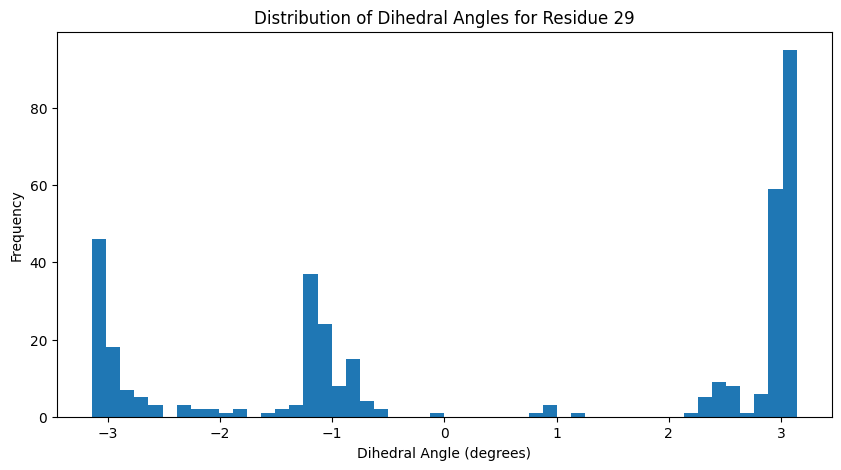

In [12]:
fig = plt.figure(figsize=(10,5))
plt.hist(flat_lst_angles_per_res[idx], bins=50)
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Dihedral Angles for Residue {}".format(idx) )
plt.show()
idx += 1

## Save Angles

In [13]:
save_dir = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/xi1anlges")
with open( save_dir.joinpath("dihedral_angles_per_residue.pkl"), "wb") as f:
    pkl.dump( flat_lst_angles_per_res, f)